# Metropolis-Hastings en dos dimensiones

En este trabajo uso Metropolis-Hastings para generar una cadena de puntos con dos coordenadas, $x_1$ y $x_2$. Mi objetivo es explicar cómo hago las propuestas, cómo decido si las acepto y cómo represento los valores que obtengo.

Primero defino la densidad y el simulador. Después genero los puntos y hago una nube de puntos y dos histogramas, uno para cada coordenada.

## 1. Bibliotecas que uso

Con **NumPy** genero los números aleatorios, guardo la muestra y cuento los valores de los histogramas. Con **Pillow (`PIL`)** dibujo las gráficas y las guardo como imágenes. Uso **`display`** para mostrarlas en el cuaderno.

In [1]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

## 2. Densidad con la que trabajo

Parto de la densidad que está definida en el código:

$$
f(x_1,x_2)=C\exp\!\left[-\frac12\left(x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2\right)\right],
\qquad (x_1,x_2)\in\mathbb{R}^2.
$$

Aquí $C>0$ hace que la densidad integre uno. No necesito calcularla para hacer la simulación, porque se cancela en el cociente $f(Y)/f(X_t)$.

En `log_densidad_sin_constante` calculo el logaritmo de la densidad sin incluir la constante:

$$
\ell(x_1,x_2)=-\frac12\left(x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2\right).
$$

Lo que hago aquí es separar `x` en `x1` y `x2`, calcular el polinomio y devolver `-polinomio / 2`. Como $\log f(x)=\log C+\ell(x)$, al restar obtengo

$$
\ell(Y)-\ell(X_t)=\log\left(\frac{f(Y)}{f(X_t)}\right).
$$

Un valor mayor de $\ell$ corresponde a una densidad mayor. Este valor puede ser positivo; no lo trato como una probabilidad.

In [2]:
def log_densidad_sin_constante(x):
    x1, x2 = x

    polinomio = (
        x1**2 * x2**2
        + x1**2
        + x2**2
        - 8 * x1
        - 8 * x2
    )

    return -polinomio / 2

## 3. Cómo hago la caminata

Empiezo en $X_0=(0,0)$. En cada paso hago lo siguiente:

1. Genero $Z=(Z_1,Z_2)$ con dos normales estándar independientes y propongo el punto $Y=X_t+Z$.
2. Calculo la probabilidad de aceptar la propuesta:

   $$\alpha(X_t,Y)=\min\left(1,\frac{f(Y)}{f(X_t)}\right).$$

3. Genero $U\sim\operatorname{Uniforme}(0,1)$. Si $U\leq\alpha$, acepto $Y$. Si no, me quedo en $X_t$.
4. Guardo el punto resultante en la siguiente fila de `muestra`, aunque se repita.

### Regla de aceptación

La propuesta normal es simétrica: $q(y\mid x)=q(x\mid y)$. Esto significa que la densidad de proponer $y$ desde $x$ es igual a la de proponer $x$ desde $y$. Por eso se cancela el cociente de propuestas de la fórmula general de Metropolis-Hastings. También se cancela la constante $C$.

En el código calculo la misma probabilidad usando los logaritmos:

$$\alpha=\exp\!\left(\min\{0,\ell(Y)-\ell(X_t)\}\right).$$

Así evito calcular dos exponenciales por separado y después dividirlas. Si el punto propuesto tiene mayor o igual densidad, lo acepto siempre. Si tiene menor densidad, todavía puedo aceptarlo, pero con una probabilidad menor que uno.

### Variables del simulador

| Variable | Lo que representa |
|---|---|
| `x_actual` | Punto en el que está la cadena. |
| `z` | Movimiento normal que genero. |
| `y` | Punto que propongo. |
| `log_f_actual`, `log_f_y` | Valores de $\ell$ en el punto actual y en la propuesta. |
| `alfa`, `u` | Probabilidad de aceptación y número con el que tomo la decisión. |
| `muestra[t]` | Punto que guardo después de aceptar o rechazar. |
| `aceptadas` | Número de propuestas que acepto. |

En `n` cuento los puntos que guardo, incluyendo el inicial. Entonces hago `n - 1` propuestas y calculo la tasa de aceptación como `aceptadas / (n - 1)`. La muestra tiene `n` filas y dos columnas.

Cuando rechazo una propuesta, guardo otra vez el punto actual. **Conservo esas repeticiones**, porque forman parte de la cadena. Si las eliminara, cambiaría las frecuencias de las regiones visitadas. Además, los puntos consecutivos pueden estar relacionados; no los considero observaciones independientes.

Antes de empezar verifico que `n` sea un entero positivo y que el punto inicial tenga dos valores finitos.

In [3]:
def simular(n, x_inicial=(0.0, 0.0), semilla=None):
    if isinstance(n, (bool, np.bool_)) or not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError("n debe ser un entero positivo")

    rng = np.random.default_rng(semilla)
    x_actual = np.asarray(x_inicial, dtype=float)

    if x_actual.shape != (2,):
        raise ValueError("x_inicial debe tener dos componentes")

    if not np.isfinite(x_actual).all():
        raise ValueError("x_inicial debe contener valores finitos")

    log_f_actual = log_densidad_sin_constante(x_actual)

    # Guardo un vector X_t = (x1, x2) en cada fila.
    muestra = np.empty((n, 2), dtype=float)
    muestra[0] = x_actual

    aceptadas = 0

    for t in range(1, n):
        # Genero dos normales estándar independientes.
        z = rng.normal(loc=0.0, scale=1.0, size=2)
        y = x_actual + z

        log_f_y = log_densidad_sin_constante(y)

        # alfa = min(1, f(y) / f(x_actual)).
        alfa = np.exp(min(0.0, log_f_y - log_f_actual))
        u = rng.random()

        if u <= alfa:
            x_actual = y
            log_f_actual = log_f_y
            aceptadas += 1

        # Si rechazo la propuesta, guardo otra vez x_actual.
        muestra[t] = x_actual

    tasa_aceptacion = aceptadas / (n - 1) if n > 1 else 0.0

    return muestra, tasa_aceptacion

## 4. Cómo dibujo la muestra

Con `guardar_grafico` dibujo cada par $(x_1,x_2)$ como un punto. Tomo los mínimos y máximos para poner los límites y agrego un margen para que los puntos no queden pegados al borde.

En el eje horizontal pongo $x_1$ y en el vertical pongo $x_2$. Así veo las dos coordenadas juntas y las regiones que visita la cadena. Uso transparencia al dibujar los puntos; algunos pueden quedar uno encima de otro.

Esta figura es una nube de puntos. No une las posiciones en el orden de la caminata y no permite ver directamente cómo cambia cada coordenada con el tiempo.

In [4]:
def guardar_grafico(muestra, ruta, tasa_aceptacion=None):
    ancho, alto = 1100, 850
    izquierda, derecha = 105, 1040
    arriba, abajo = 100, 755

    imagen = Image.new("RGB", (ancho, alto), "white")
    dibujo = ImageDraw.Draw(imagen, "RGBA")

    minimo = muestra.min(axis=0)
    maximo = muestra.max(axis=0)
    margen = np.maximum((maximo - minimo) * 0.08, 0.5)

    x_min, y_min = minimo - margen
    x_max, y_max = maximo + margen

    def pixel_x(x):
        return izquierda + (x - x_min) / (x_max - x_min) * (derecha - izquierda)

    def pixel_y(y):
        return abajo - (y - y_min) / (y_max - y_min) * (abajo - arriba)

    try:
        fuente = ImageFont.truetype("DejaVuSans.ttf", size=19)
        fuente_titulo = ImageFont.truetype("DejaVuSans.ttf", size=28)
    except OSError:
        fuente = ImageFont.load_default(size=19)
        fuente_titulo = ImageFont.load_default(size=28)

    # Cuadrícula y marcas de los ejes.
    for valor in np.linspace(x_min, x_max, 6):
        px = pixel_x(valor)
        dibujo.line(
            (px, arriba, px, abajo),
            fill=(220, 226, 235, 255),
            width=1
        )
        dibujo.text(
            (px - 22, abajo + 12),
            f"{valor:.1f}",
            font=fuente,
            fill="black"
        )

    for valor in np.linspace(y_min, y_max, 6):
        py = pixel_y(valor)
        dibujo.line(
            (izquierda, py, derecha, py),
            fill=(220, 226, 235, 255),
            width=1
        )
        dibujo.text(
            (25, py - 10),
            f"{valor:.1f}",
            font=fuente,
            fill="black"
        )

    # Un punto por cada vector simulado.
    for x1, x2 in muestra:
        px = pixel_x(x1)
        py = pixel_y(x2)
        dibujo.ellipse(
            (px - 2, py - 2, px + 2, py + 2),
            fill=(30, 93, 175, 30)
        )

    dibujo.rectangle(
        (izquierda, arriba, derecha, abajo),
        outline=(55, 65, 80, 255),
        width=2
    )

    dibujo.text(
        (izquierda, 28),
        "Muestra simulada por Metropolis-Hastings",
        font=fuente_titulo,
        fill="black"
    )

    dibujo.text(
        ((izquierda + derecha) / 2 - 13, alto - 55),
        "x1",
        font=fuente,
        fill="black"
    )

    dibujo.text(
        (25, 60),
        "x2",
        font=fuente,
        fill="black"
    )

    detalle = f"N = {len(muestra):,}"

    if tasa_aceptacion is not None:
        detalle += f"   |   Aceptacion = {tasa_aceptacion:.1%}"

    dibujo.text(
        (izquierda, 68),
        detalle,
        font=fuente,
        fill=(70, 80, 95, 255)
    )

    imagen.save(ruta)

## 5. Simulación

Guardo `10_000` puntos, empiezo en `(0.0, 0.0)` y fijo `semilla = 42`. Con la misma semilla, el mismo código y el mismo entorno puedo repetir la simulación.

La función me devuelve `muestra` y `tasa`. Muestro los primeros diez puntos, imprimo la tasa de aceptación y dibujo la nube de puntos.

Para esta ejecución hago **9 999 propuestas**, porque el primer punto es el estado inicial. Uso todos los puntos guardados, incluyendo el inicial y las repeticiones por rechazo. No descarto una parte inicial de la cadena.

La tasa de aceptación me dice qué proporción de las propuestas acepto. Por sí sola no me permite asegurar que la cadena haya explorado bien la distribución.

Primeros 10 vectores:
[[ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.1278404  -0.31624259]
 [ 0.1278404  -0.31624259]
 [ 0.1938711   0.81099861]
 [ 0.1938711   0.81099861]
 [ 1.0723214   0.7610727 ]
 [ 0.39139186  1.98361404]
 [ 0.39139186  1.98361404]]
Tasa de aceptación: 30.7%


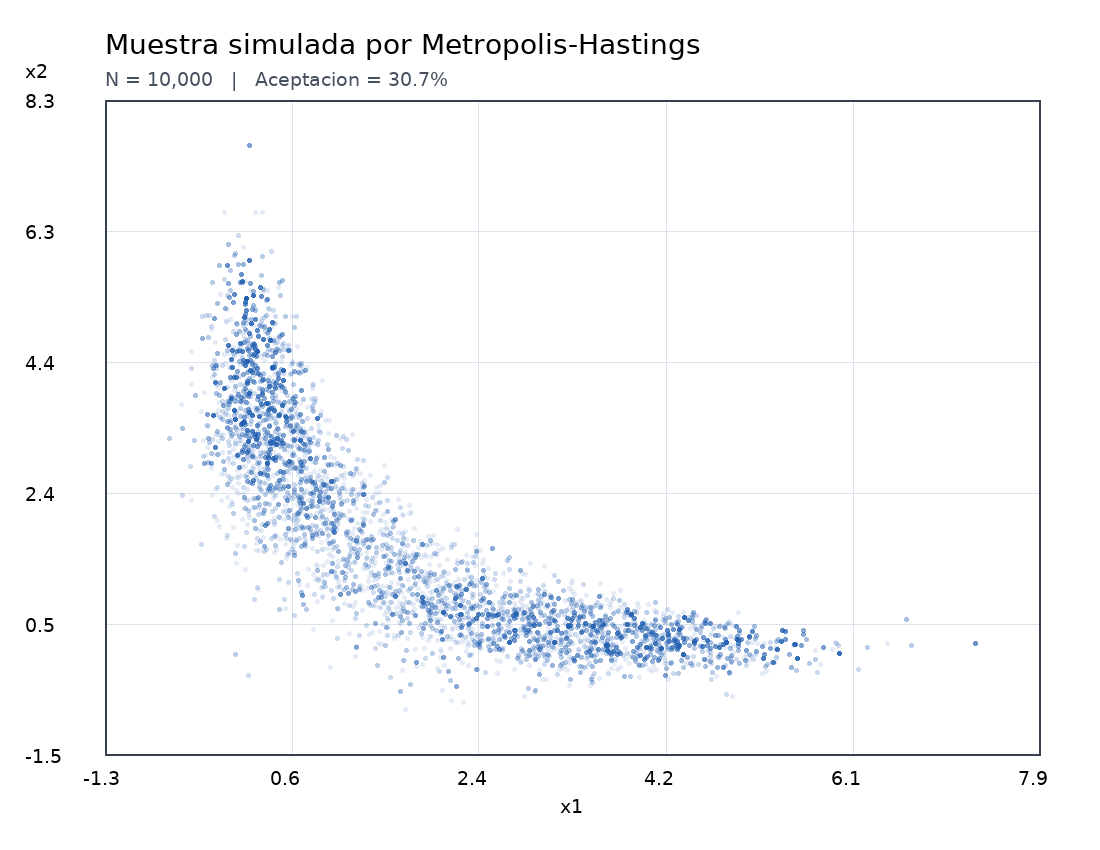

In [5]:
N = 10_000

muestra, tasa = simular(
    n=N,
    x_inicial=(0.0, 0.0),
    semilla=42
)

ruta_grafico = "grafico_metropolis_hastings.png"
guardar_grafico(muestra, ruta_grafico, tasa)

print("Primeros 10 vectores:")
print(muestra[:10])
print(f"Tasa de aceptación: {tasa:.1%}")

display(Image.open(ruta_grafico))

## 6. Histogramas de las dos coordenadas

Hago un histograma para $x_1$ y otro para $x_2$, usando la misma muestra que ya generé:

- Con `muestra[:, 0]` tomo todos los valores de $x_1$.
- Con `muestra[:, 1]` tomo todos los valores de $x_2$.

Divido los valores en intervalos y cuento cuántos caen en cada uno. La altura de cada barra es ese conteo. Por eso el eje vertical muestra **frecuencia absoluta**, no una densidad ni una probabilidad.

Uso `np.histogram` con **40 intervalos**. Mantengo los mismos intervalos y la misma escala vertical en las dos gráficas para compararlas. Cambiar el número de intervalos modifica cómo se ven las barras, pero no modifica los datos.

Los llamo histogramas marginales porque veo cada coordenada por separado. Si la cadena explora adecuadamente la distribución, estas frecuencias me ayudan a aproximar el comportamiento de cada variable. Para ver las dos coordenadas juntas uso la nube de puntos.

En la función verifico que la muestra tenga dos columnas, al menos una fila y valores finitos. También compruebo que el número de intervalos sea un entero positivo. Si todos los valores son iguales, agrego un margen al rango para poder dibujar el histograma.

In [6]:
def guardar_histogramas(muestra, ruta, intervalos=40):
    muestra = np.asarray(muestra, dtype=float)
    if muestra.ndim != 2 or muestra.shape[1] != 2 or muestra.shape[0] == 0:
        raise ValueError("muestra debe tener al menos una fila y dos columnas")
    if not np.isfinite(muestra).all():
        raise ValueError("muestra debe contener valores finitos")
    if isinstance(intervalos, (bool, np.bool_)) or not isinstance(intervalos, (int, np.integer)) or intervalos < 1:
        raise ValueError("intervalos debe ser un entero positivo")

    # Uso los mismos intervalos y la misma escala en los dos paneles.
    minimo, maximo = muestra.min(), muestra.max()
    if minimo == maximo:
        minimo, maximo = minimo - 0.5, maximo + 0.5
    bordes = np.linspace(minimo, maximo, intervalos + 1)
    conteos = [
        np.histogram(muestra[:, j], bins=bordes)[0]
        for j in range(2)
    ]
    limite_y = max(conteo.max() for conteo in conteos) * 1.12

    ancho, alto = 1400, 680
    imagen = Image.new("RGB", (ancho, alto), "white")
    dibujo = ImageDraw.Draw(imagen)

    try:
        fuente = ImageFont.truetype("DejaVuSans.ttf", size=20)
        fuente_titulo = ImageFont.truetype("DejaVuSans.ttf", size=30)
    except OSError:
        fuente = ImageFont.load_default(size=20)
        fuente_titulo = ImageFont.load_default(size=30)

    dibujo.text((80, 25), "Histogramas marginales de la cadena", font=fuente_titulo, fill="#14283f")
    detalle = f"N = {len(muestra):,} estados | {intervalos} intervalos | Incluye estados repetidos e inicial"
    dibujo.text((80, 75), detalle, font=fuente, fill="#46586b")

    colores = ["#277da8", "#dc8741"]
    for j in range(2):
        izquierda, derecha = 100 + j * 680, 670 + j * 680
        arriba, abajo = 170, 535

        def pixel_x(valor):
            return izquierda + (valor - bordes[0]) / (bordes[-1] - bordes[0]) * (derecha - izquierda)

        def pixel_y(valor):
            return abajo - valor / limite_y * (abajo - arriba)

        dibujo.text((izquierda, 125), f"x{j + 1} | Frecuencia (conteo)", font=fuente, fill="#14283f")

        for valor in np.linspace(0, limite_y, 6):
            py = pixel_y(valor)
            dibujo.line((izquierda, py, derecha, py), fill="#e0e6ed")
            dibujo.text((izquierda - 15, py), f"{valor:.0f}", anchor="rm", font=fuente, fill="#46586b")

        for k, conteo in enumerate(conteos[j]):
            if conteo > 0:
                dibujo.rectangle(
                    (pixel_x(bordes[k]), pixel_y(conteo), pixel_x(bordes[k + 1]), abajo),
                    fill=colores[j], outline="white"
                )

        dibujo.rectangle((izquierda, arriba, derecha, abajo), outline="#46586b", width=2)
        for valor in np.linspace(bordes[0], bordes[-1], 6):
            px = pixel_x(valor)
            dibujo.line((px, abajo, px, abajo + 6), fill="#46586b", width=2)
            dibujo.text((px, abajo + 16), f"{valor:.1f}", anchor="mt", font=fuente, fill="#46586b")

        dibujo.text(((izquierda + derecha) / 2, 588), f"Valores de x{j + 1}", anchor="mt", font=fuente, fill="#14283f")

    imagen.save(ruta)
    return conteos, bordes

### Generación y conteo

Guardo la imagen de los histogramas y la muestro en el cuaderno. Conservo los puntos repetidos por rechazo.

Para comprobar el conteo, sumo las frecuencias. En cada histograma debe salir `len(muestra)`, porque cada punto aporta un valor de $x_1$ y uno de $x_2$. Los intervalos cubren todos los valores; el último también incluye su extremo derecho.

Estados almacenados: 10,000
Total contado para x1: 10,000
Total contado para x2: 10,000


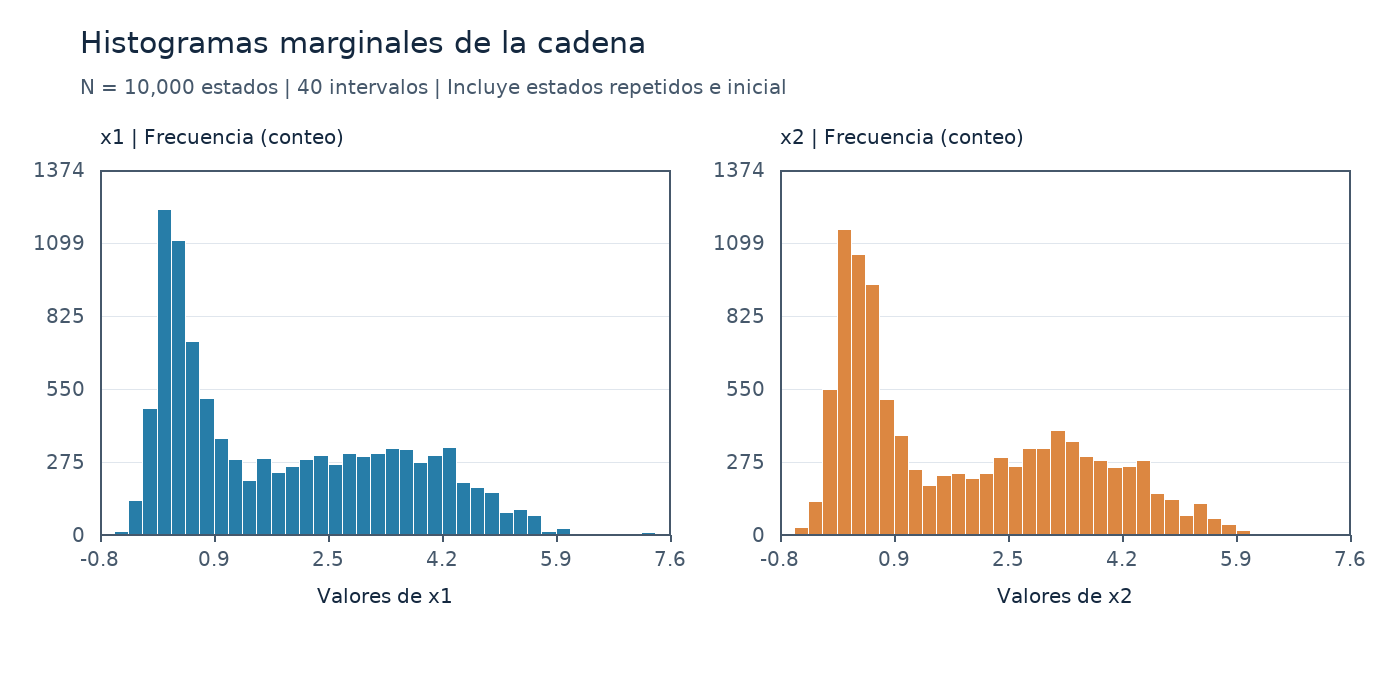

In [7]:
ruta_histogramas = "histogramas_metropolis_hastings.png"
conteos, bordes = guardar_histogramas(muestra, ruta_histogramas, intervalos=40)

print(f"Estados almacenados: {len(muestra):,}")
print(f"Total contado para x1: {conteos[0].sum():,}")
print(f"Total contado para x2: {conteos[1].sum():,}")
display(Image.open(ruta_histogramas))

## 7. Comprobaciones de la ejecución

Reviso que la muestra tenga `10_000` filas y dos columnas, que no tenga valores no finitos y que cada histograma cuente todos los puntos.

También cuento cuántas veces cambió el punto entre dos filas consecutivas. Para esta ejecución, esos cambios corresponden a las propuestas aceptadas. El resto de las transiciones conserva el punto anterior. Comparo este conteo con la tasa que devuelve el simulador.

Estas comprobaciones revisan el almacenamiento y los conteos. No son una prueba de convergencia de la cadena.

In [8]:
propuestas = len(muestra) - 1
cambios = np.any(muestra[1:] != muestra[:-1], axis=1)
aceptadas = int(cambios.sum())
rechazadas = propuestas - aceptadas

assert muestra.shape == (N, 2)
assert np.isfinite(muestra).all()
assert np.array_equal(muestra[0], np.array([0.0, 0.0]))
assert all(conteo.sum() == len(muestra) for conteo in conteos)
assert np.isclose(tasa, aceptadas / propuestas)

print(f"Puntos guardados: {len(muestra):,}")
print(f"Propuestas: {propuestas:,}")
print(f"Aceptadas: {aceptadas:,}")
print(f"Rechazadas: {rechazadas:,}")
print(f"Tasa de aceptación: {tasa:.4%}")
print("Las comprobaciones de esta ejecución se cumplieron.")

Puntos guardados: 10,000
Propuestas: 9,999
Aceptadas: 3,065
Rechazadas: 6,934
Tasa de aceptación: 30.6531%
Las comprobaciones de esta ejecución se cumplieron.


## 8. Resultados y conclusión

En esta ejecución guardé **10 000 puntos** y realicé **9 999 propuestas**. Acepté **3 065** y rechacé **6 934**. La tasa de aceptación fue aproximadamente **30.7 %**. Cada histograma contó los **10 000 valores** de su coordenada, incluyendo las repeticiones.

En la nube de puntos observo una región con forma curva: cuando una coordenada toma valores altos, la otra suele mantenerse más cerca de cero. En los histogramas veo una concentración marcada de valores pequeños y otra zona más extendida hacia valores positivos mayores. Estas observaciones describen los puntos que obtuve en esta simulación.

La densidad es simétrica al intercambiar $x_1$ y $x_2$, por lo que las dos distribuciones marginales teóricas son iguales. Mis histogramas no tienen que coincidir barra por barra, porque uso una cantidad finita de puntos relacionados entre sí. No interpreto sus diferencias como una prueba de que las marginales teóricas sean distintas.

Con este procedimiento genero propuestas normales, aplico la regla de aceptación y conservo el estado anterior cuando rechazo un movimiento. La nube de puntos me permite ver las coordenadas juntas y los histogramas me permiten revisar sus frecuencias por separado.

La ejecución y los conteos fueron consistentes con el código. Aun así, con estas gráficas y la tasa de aceptación no puedo afirmar que la cadena haya convergido ni que los puntos sean independientes. Mi conclusión se limita a describir esta ejecución de Metropolis-Hastings.